In [214]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

In [111]:
housing = fetch_california_housing()

In [112]:
data = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)
df = data.copy()
df["Price"] = housing.target
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [113]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [114]:
df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [115]:
df.sample(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
7557,2.0134,35.0,3.817280,1.059490,2935.0,4.157224,33.91,-118.19,1.324
19146,3.3750,26.0,5.369492,1.000000,846.0,2.867797,38.33,-122.70,1.563
15907,4.2212,52.0,4.506696,0.933036,999.0,2.229911,37.74,-122.42,2.713
8970,4.6687,44.0,5.782016,1.049046,1012.0,2.757493,34.00,-118.40,3.443
16338,5.6147,16.0,7.411111,1.022222,267.0,2.966667,38.05,-121.34,2.447


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [117]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [118]:
df[df["AveRooms"] > 10]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
1023,2.2417,15.0,10.515306,2.372449,573.0,2.923469,38.72,-119.93,0.979
1024,3.1500,16.0,29.852941,5.323529,202.0,1.980392,38.52,-120.00,1.406
1030,3.0125,15.0,10.168591,2.057737,1103.0,2.547344,38.55,-120.25,1.117
1102,2.4028,17.0,31.777778,9.703704,47.0,1.740741,40.06,-121.54,0.675
1233,3.7500,10.0,16.847534,3.237668,546.0,2.448430,38.23,-120.34,1.214
...,...,...,...,...,...,...,...,...,...
20093,2.0625,37.0,24.669118,4.897059,338.0,2.485294,38.12,-120.12,0.889
20094,2.1250,26.0,37.063492,7.185185,416.0,2.201058,38.19,-120.03,1.325
20110,3.2589,9.0,11.458508,2.056161,2811.0,2.356245,37.84,-120.20,1.379
20112,4.0833,18.0,11.536585,2.804878,88.0,2.146341,37.85,-119.93,1.375


In [119]:
df[df["AveBedrms"] > 5].count()

MedInc        45
HouseAge      45
AveRooms      45
AveBedrms     45
Population    45
AveOccup      45
Latitude      45
Longitude     45
Price         45
dtype: int64

In [120]:
df[df["AveOccup"] > 7].count()

MedInc        70
HouseAge      70
AveRooms      70
AveBedrms     70
Population    70
AveOccup      70
Latitude      70
Longitude     70
Price         70
dtype: int64

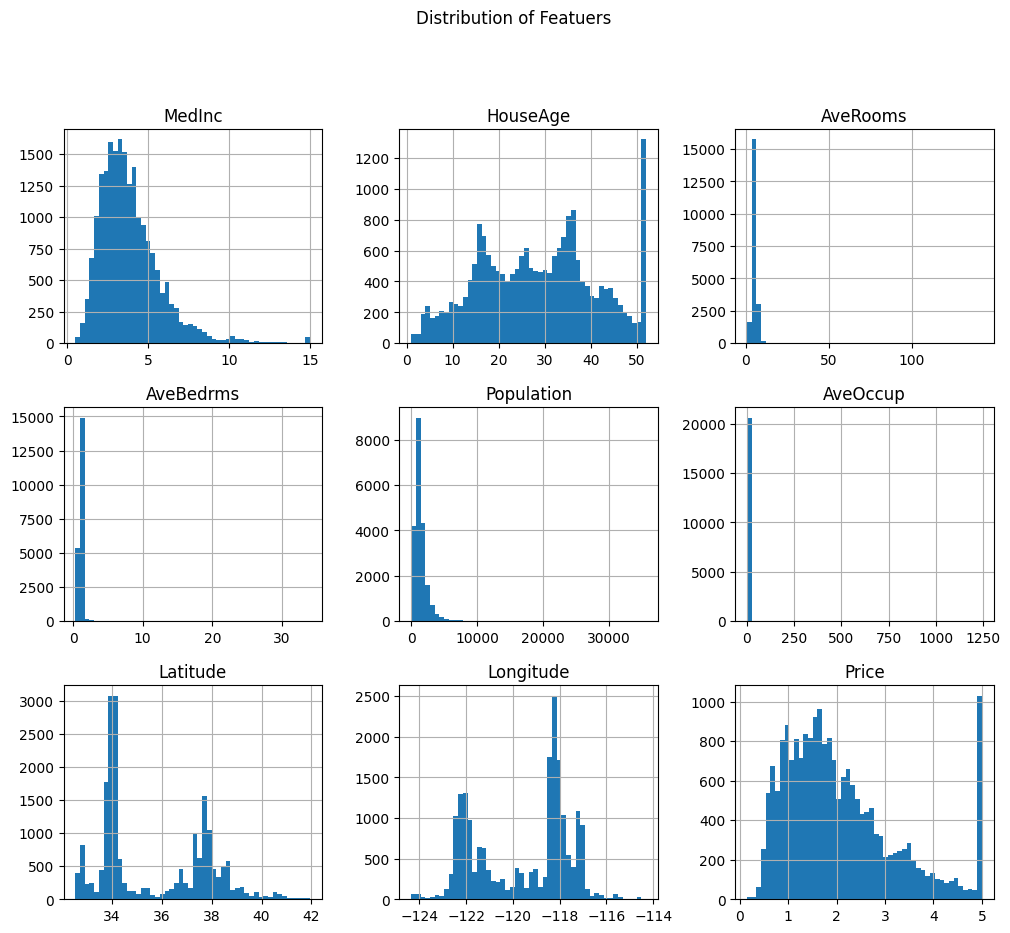

In [121]:
df.hist(figsize=(12, 10), bins=50)
plt.suptitle("Distribution of Featuers",y=1)
plt.show()


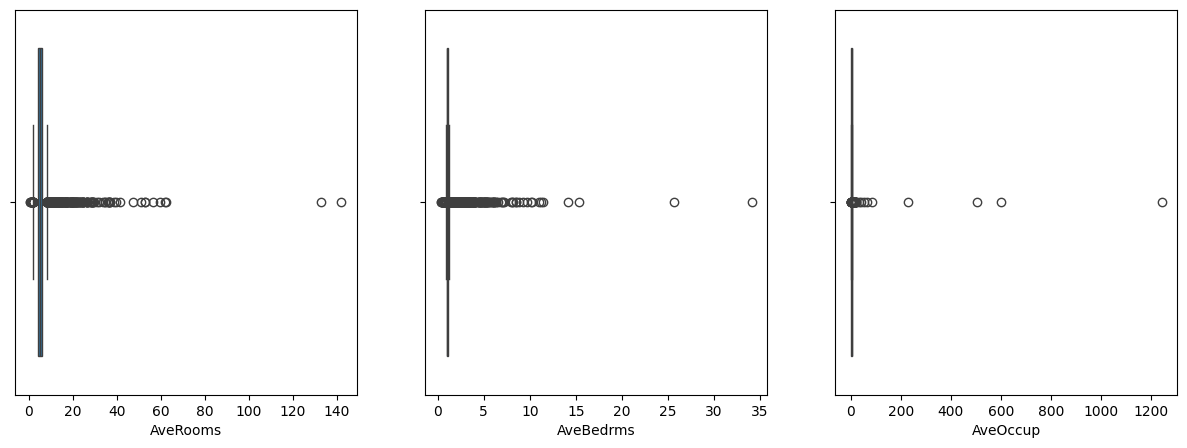

In [122]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(x=df['AveRooms'], ax=axes[0])
sns.boxplot(x=df['AveBedrms'], ax=axes[1])
sns.boxplot(x=df['AveOccup'], ax=axes[2])
plt.show()

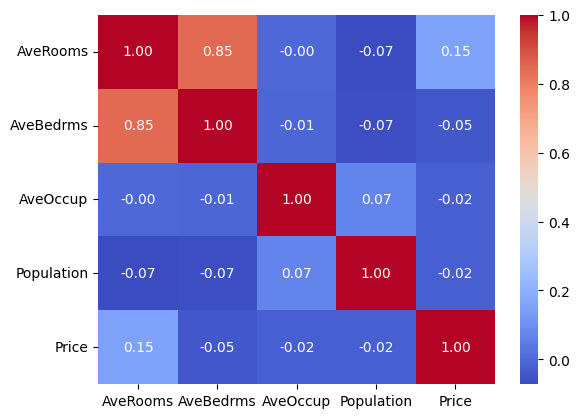

In [123]:
sns.heatmap(df[['AveRooms', 'AveBedrms', 'AveOccup', 'Population', 'Price']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.show()


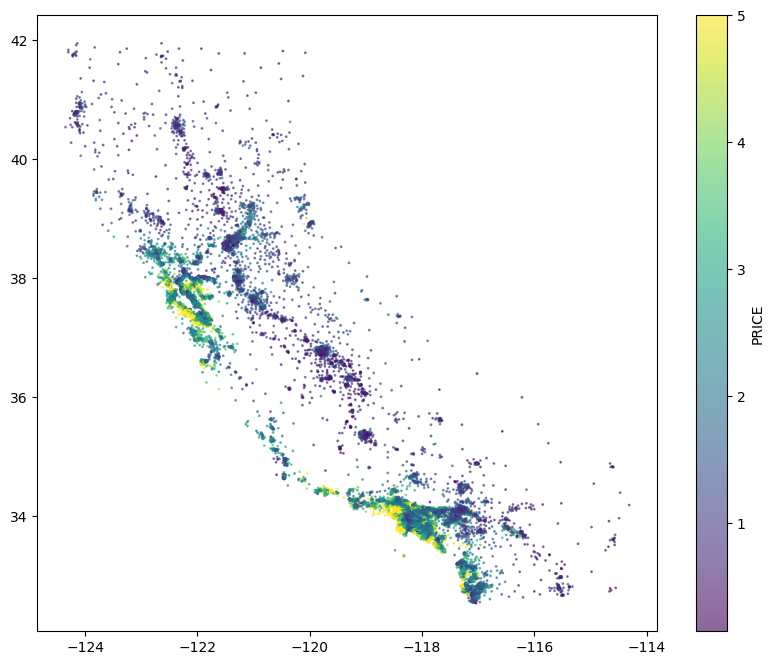

In [124]:
plt.figure(figsize=(10, 8))
plt.scatter(df['Longitude'], df['Latitude'], 
            c=df['Price'], cmap='viridis', alpha=0.6, s=1)
plt.colorbar(label='PRICE')

plt.show()

# بعداز حذف داده های پرت

In [125]:
df['AveRooms'] = df['AveRooms'].clip(upper=df['AveRooms'].quantile(0.99))
df['AveBedrms'] = df['AveBedrms'].clip(upper=df['AveBedrms'].quantile(0.99))
df['AveOccup'] = df['AveOccup'].clip(upper=df['AveOccup'].quantile(0.99))
df['Population'] = df['Population'].clip(upper=df['Population'].quantile(0.99))

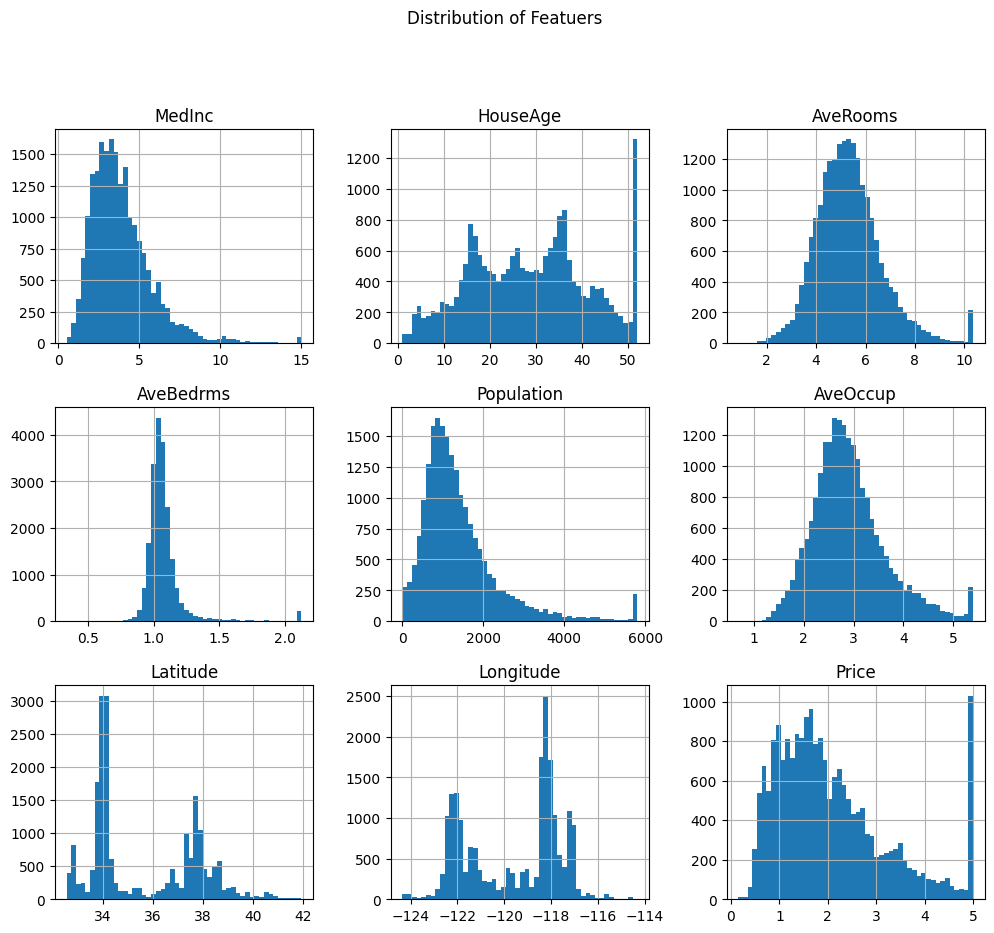

In [126]:
df.hist(figsize=(12, 10), bins=50)
plt.suptitle("Distribution of Featuers",y=1)
plt.show()

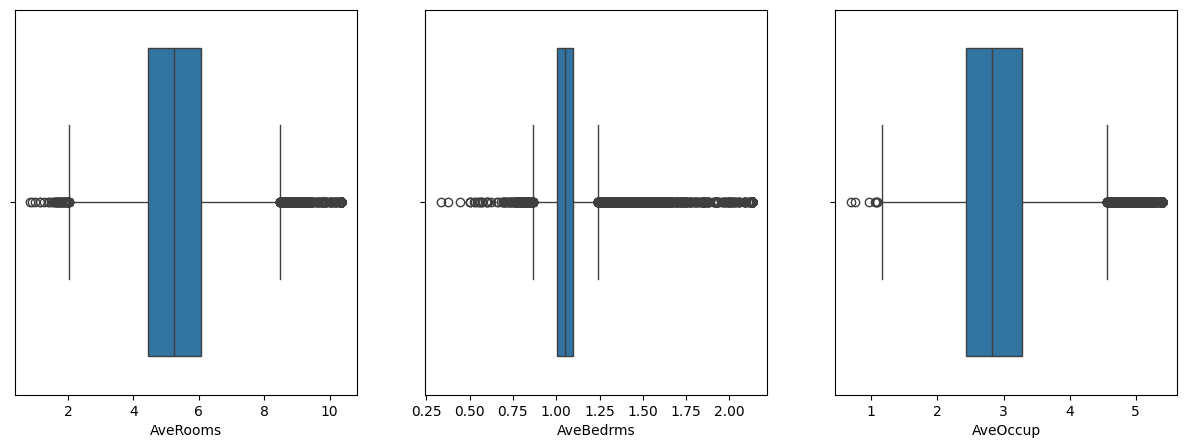

In [127]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(x=df['AveRooms'], ax=axes[0])
sns.boxplot(x=df['AveBedrms'], ax=axes[1])
sns.boxplot(x=df['AveOccup'], ax=axes[2])
plt.show()

In [128]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [129]:
st_scaler = StandardScaler()
df["Population"] = st_scaler.fit_transform(df[["Population"]])

In [130]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,-1.111111,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,1.024586,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,-0.932366,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,-0.868675,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,-0.861484,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,-0.573848,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,-1.076184,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,-0.407430,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,-0.680684,2.123209,39.43,-121.32,0.847


In [131]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [132]:
x

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,-1.111111,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,1.024586,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,-0.932366,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,-0.868675,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,-0.861484,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,-0.573848,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,-1.076184,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,-0.407430,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,-0.680684,2.123209,39.43,-121.32


In [133]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: Price, Length: 20640, dtype: float64

In [134]:
x_train,x_test , y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [136]:
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [137]:
model.score(x_train,y_train)

0.6637963972816266

In [138]:
model.score(x_test,y_test)

0.6573463935240653

In [139]:
model.score(x,y)

0.6618892952299886

In [217]:
y_pred = model.predict(x_test)

In [213]:
gpu_model = xgb.XGBRegressor(n_estimators=150,learning_rate = 0.1,max_depth=5,subsample=0.8,colsample_bytree=0.8,reg_alpha=0.1,reg_lambda=1.0,device = "cuda")
gpu_model.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabete

In [209]:
gpu_model.score(x_train,y_train)

0.8887486476598079

In [210]:
gpu_model.score(x_test,y_test)

0.8351684438065794

In [211]:
gpu_model.score(x,y)

0.8729041621606777

In [216]:
y_pred2 = gpu_model.predict(x_test)

In [220]:
# RMSE 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))

# MSE 
mse = mean_squared_error(y_test, y_pred)
mse2 = mean_squared_error(y_test, y_pred2)

# MAE
mae = mean_absolute_error(y_test, y_pred)
mae2 = mean_absolute_error(y_test, y_pred2)

# MAPE
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
mape2= mean_absolute_percentage_error(y_test, y_pred2) * 100

In [222]:
print(f"RMSE FOR LIN_REG : {rmse} \n")
print(f"RMSE FOR XGBOOST : {rmse2}\n")

print(f"MSE FOR LIN_REG : {mse}\n")
print(f"MSE FOR XGBOOST : {mse2}\n")
        
print(f"MAE FOR LIN_REG : {mae}\n")
print(f"MAE FOR XGBOOST : {mae2}\n")
        
print(f"MAPE FOR LIN_REG : {mape}\n")
print(f"MAPE FOR XGBOOST : {mape2}\n")
        
        

RMSE FOR LIN_REG : 0.6706314946278115 

RMSE FOR XGBOOST : 0.4651322699375299

MSE FOR LIN_REG : 0.44974660158673235

MSE FOR XGBOOST : 0.21634802853723917

MAE FOR LIN_REG : 0.49344521455988777

MAE FOR XGBOOST : 0.31324906473948355

MAPE FOR LIN_REG : 30.109956253329866

MAPE FOR XGBOOST : 18.132846700741812

